# Ridge Regression

## Review 1 — Regression Track

**Dataset:** Ames Housing  
**Target:** `SalePrice`  
**Notebook:** `02_ridge_regression.ipynb`

This notebook implements the **Ridge Regression** as one of the ten required regression algorithms.  
All regression notebooks use the same dataset, `random_state=42`, 80:20 held-out split, feature engineering, missing-value handling, and leakage-safe preprocessing so that model comparisons are fair.


## 1. Imports and Project Paths

In [7]:
from pathlib import Path
import sys
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Locate project root
cwd = Path.cwd().resolve()

candidates = [cwd] + list(cwd.parents)

PROJECT_ROOT = next(
    (p for p in candidates if (p / "src" / "preprocessing.py").exists()),
    cwd
)

# Add src to Python path
sys.path.insert(0, str(PROJECT_ROOT / "src"))

from preprocessing import (
    RANDOM_STATE,
    TARGET,
    load_and_engineer,
    split_data,
    remove_training_outliers,
    make_preprocessor,
    make_polynomial_preprocessor,
    regression_metrics,
)

# Correct paths
DATA_PATH = PROJECT_ROOT / "data" / "AmesHousing.csv"
RESULTS_DIR = PROJECT_ROOT / "results"
MODELS_DIR = PROJECT_ROOT / "models"

RESULTS_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid")

## 2. Load Dataset and Perform the Required Audit

We report dataset shape, data types, missing-value counts, duplicate rows, and the target distribution.

In [4]:
df, X, y = load_and_engineer(DATA_PATH)

print(f"Dataset shape: {df.shape}")
display(df.head())

print("\nData types:")
display(df.dtypes.value_counts().rename_axis("dtype").reset_index(name="count"))

print("\nMissing values — top 20:")
display(df.isna().sum().sort_values(ascending=False).head(20).to_frame("missing_count"))

print("\nDuplicate rows:", df.duplicated().sum())

print("\nTarget distribution:")
display(y.describe().to_frame("SalePrice"))

print("\nCategorical features:", len(X.select_dtypes(include="object").columns))
print("Numerical features:", len(X.select_dtypes(include=np.number).columns))

Dataset shape: (2930, 84)


,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice,TotalSF,TotalBathrooms
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,...,NaN,NaN,0,5,2010,WD,Normal,215000,2736.0,2.0
1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,...,MnPrv,NaN,0,6,2010,WD,Normal,105000,1778.0,1.0
2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,...,NaN,Gar2,12500,6,2010,WD,Normal,172000,2658.0,1.5
3,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,...,NaN,NaN,0,4,2010,WD,Normal,244000,4220.0,3.5
4,5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,...,MnPrv,NaN,0,3,2010,WD,Normal,189900,2557.0,2.5



Data types:


,dtype,count
0,object,43
1,int64,28
2,float64,13



Missing values — top 20:


,missing_count
Pool QC,2917
Misc Feature,2824
Alley,2732
Fence,2358
Mas Vnr Type,1775
Fireplace Qu,1422
Lot Frontage,490
Garage Finish,159
Garage Yr Blt,159
Garage Qual,159



Duplicate rows: 0

Target distribution:


,SalePrice
count,2930.000000
mean,180796.060068
std,79886.692357
min,12789.000000
25%,129500.000000
50%,160000.000000
75%,213500.000000
max,755000.000000



Categorical features: 44
Numerical features: 37


## 3. Exploratory Data Analysis

The following cells provide the Review 1 EDA requirements: feature distributions, target distribution, correlation heatmap, and feature-target scatter plots.

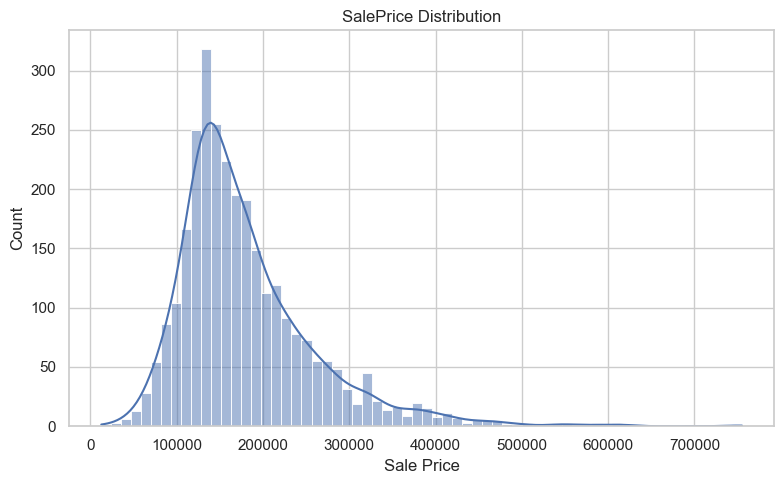

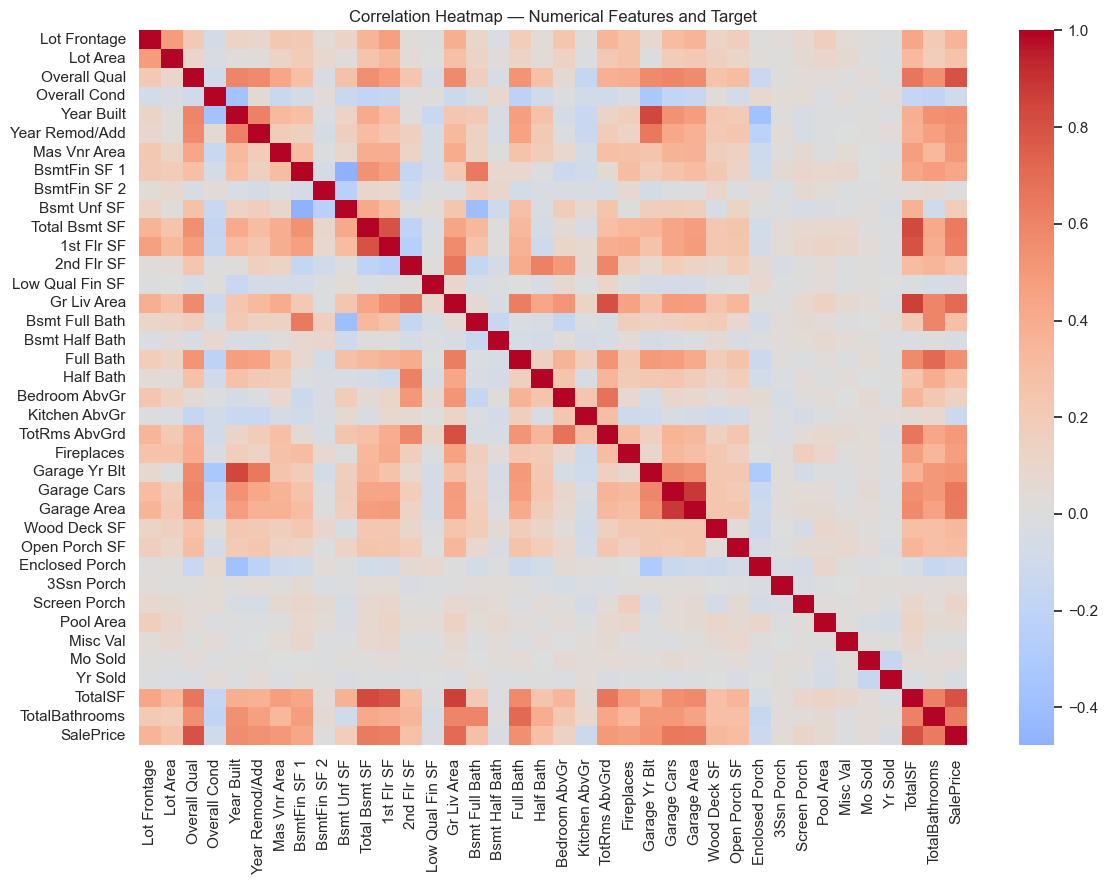

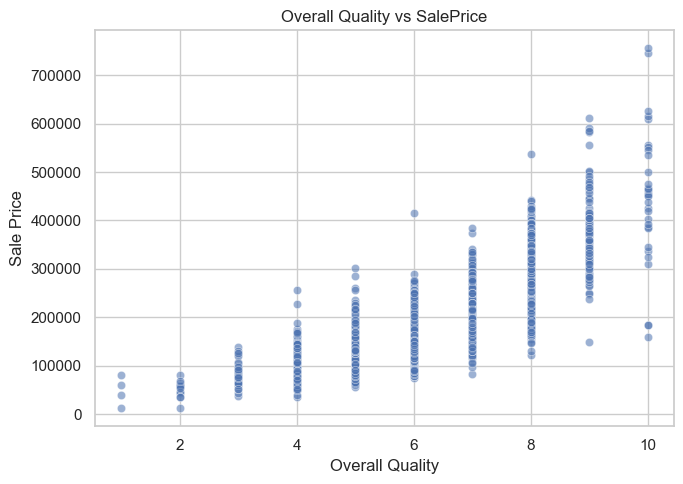

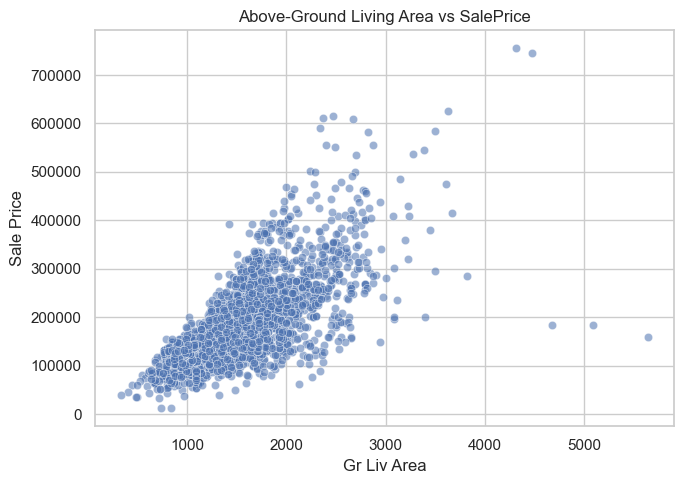

In [ ]:

numeric_cols = X.select_dtypes(include=np.number).columns.tolist()
plt.figure(figsize=(8, 5))

sns.histplot(y, kde=True)

plt.title("SalePrice Distribution")
plt.xlabel("Sale Price")
plt.ylabel("Count")

plt.tight_layout()
plt.show()



corr_cols = numeric_cols + [TARGET]

corr = df[corr_cols].corr(numeric_only=True)

plt.figure(figsize=(12, 9))

sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0,
    annot=False
)

plt.title("Correlation Heatmap — Numerical Features and Target")

plt.tight_layout()
plt.show()



plt.figure(figsize=(7, 5))

sns.scatterplot(
    data=df,
    x="Overall Qual",
    y=TARGET,
    alpha=0.55
)

plt.title("Overall Quality vs SalePrice")
plt.xlabel("Overall Quality")
plt.ylabel("Sale Price")

plt.tight_layout()
plt.show()



plt.figure(figsize=(7, 5))

sns.scatterplot(
    data=df,
    x="Gr Liv Area",
    y=TARGET,
    alpha=0.55
)

plt.title("Above-Ground Living Area vs SalePrice")
plt.xlabel("Gr Liv Area")
plt.ylabel("Sale Price")

plt.tight_layout()
plt.show()

### EDA — Team Observation


* The SalePrice distribution is right-skewed, with most houses concentrated at lower to moderate prices and fewer houses having very high prices.
* Overall Qual shows a strong positive relationship with SalePrice, indicating that higher-quality houses generally have higher prices.
* Gr Liv Area also has a positive relationship with SalePrice, meaning larger above-ground living areas generally correspond to higher sale prices.
* The correlation heatmap shows that several house-related numerical features have noticeable relationships with the target, with Overall Qual being one of the most important.
* Some outliers are visible, particularly for Gr Liv Area, where a few houses have unusually large living areas compared with the rest of the dataset.
* Overall, the EDA indicates that house quality, living area, and other property characteristics are important factors associated with SalePrice.

## 4. Preprocessing and Feature Engineering

### Engineered features

Two predictor-only features are created:

- `TotalSF` = basement + first-floor + second-floor area.
- `TotalBathrooms` = full bathrooms + half bathrooms + basement bathrooms, with half bathrooms counted as 0.5.

Identifier columns (`Order` and `PID`) are excluded because they identify records rather than represent meaningful property characteristics.

The train/test split is created before data-driven imputation, encoding, scaling, or outlier threshold estimation.

In [ ]:
X_train, X_test, y_train, y_test = split_data(X, y)

print("Before outlier treatment:")
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

X_train, y_train, outlier_threshold = remove_training_outliers(
    X_train, y_train, feature="Gr Liv Area", multiplier=3.0
)

print(f"\nTraining outlier threshold for Gr Liv Area: {outlier_threshold:.2f}")
print("After outlier treatment:")
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

print("\nTarget means:")
print("Train:", y_train.mean())
print("Test :", y_test.mean())

Before outlier treatment:
X_train: (2344, 81)
X_test : (586, 81)

Training outlier threshold for Gr Liv Area: 3570.75
After outlier treatment:
X_train: (2338, 81)
X_test : (586, 81)

Target means:
Train: 177871.19118905047
Test : 189651.46928327644


### Preprocessing Strategy

- Numerical missing values → median imputation.
- Categorical missing values → most-frequent imputation.
- Categorical variables → one-hot encoding with unknown-category protection.
- Scale-sensitive algorithms → numerical standardization fitted on training data only.
- Tree-based algorithms → no feature scaling required.
- Extreme `Gr Liv Area` values are checked and training-set extremes above a 3×IQR upper threshold are removed; the threshold is learned only from the training set.

## 5. Train Ridge Regression

The model is trained only on the training split. The held-out test set is used only for final evaluation.

In [7]:
from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV

MODEL_NAME = "Ridge Regression"
RESULT_FILE = "ridge_regression"

base_model = Pipeline([
    ("preprocess", make_preprocessor(X_train, scale_numeric=True)),
    ("model", Ridge())
])

# Required hyperparameter tuning example.
param_grid = {
    "model__alpha": [0.1, 1.0, 10.0, 50.0, 100.0]
}
grid = GridSearchCV(base_model, param_grid=param_grid, scoring="r2", cv=5, n_jobs=-1)
grid.fit(X_train, y_train)

print("Best parameters:", grid.best_params_)
print("Best CV R2:", grid.best_score_)

model = grid.best_estimator_
y_pred = model.predict(X_test)

Best parameters: {'model__alpha': 10.0}
Best CV R2: 0.9195557425698953


## 6. Test-Set Evaluation

The mandatory regression metrics are **R², RMSE, and MAE**.

In [8]:
metrics = regression_metrics(y_test, y_pred)
metrics_df = pd.DataFrame([metrics], index=[MODEL_NAME])
display(metrics_df)

# Save a machine-readable result for the comparison notebook.
result_path = RESULTS_DIR / f"{RESULT_FILE}.csv"
metrics_df.reset_index(names="Model").to_csv(result_path, index=False)

print(f"Saved results to: {result_path}")

,R2,RMSE,MAE
Ridge Regression,0.896373,28824.190197,15376.355008


Saved results to: /Users/venkataramana/Documents/SEMESTERS/5TH SEMESTER/MACHINE LEARNING/ML_Capstone/Review-1/results/ridge_regression.csv


### Coefficient inspection

For linear models, coefficients can be inspected to understand which transformed features have the strongest positive or negative association with the prediction. Interpretations must be written by the project team after reviewing the actual fitted coefficients.

In [9]:
# Show the 20 largest absolute coefficients when the final estimator exposes them.
estimator = model.named_steps["model"]
if hasattr(estimator, "coef_"):
    feature_names = model.named_steps["preprocess"].get_feature_names_out()
    coef = np.ravel(estimator.coef_)
    coef_df = pd.DataFrame({"Feature": feature_names, "Coefficient": coef})
    coef_df["AbsoluteCoefficient"] = coef_df["Coefficient"].abs()
    display(coef_df.sort_values("AbsoluteCoefficient", ascending=False).head(20))

,Feature,Coefficient,AbsoluteCoefficient
108,cat__Neighborhood_StoneBr,27058.572343,27058.572343
101,cat__Neighborhood_NoRidge,18032.251754,18032.251754
93,cat__Neighborhood_GrnHill,16525.271758,16525.271758
249,cat__Kitchen Qual_Ex,14397.798773,14397.798773
190,cat__Exter Qual_Ex,13112.653948,13112.653948
157,cat__Exterior 1st_BrkFace,13104.219880,13104.219880
260,cat__Functional_Typ,12005.836196,12005.836196
102,cat__Neighborhood_NridgHt,11577.517035,11577.517035
14,num__Gr Liv Area,11257.231566,11257.231566
100,cat__Neighborhood_NWAmes,-10996.244834,10996.244834


## 8. Prediction Diagnostics

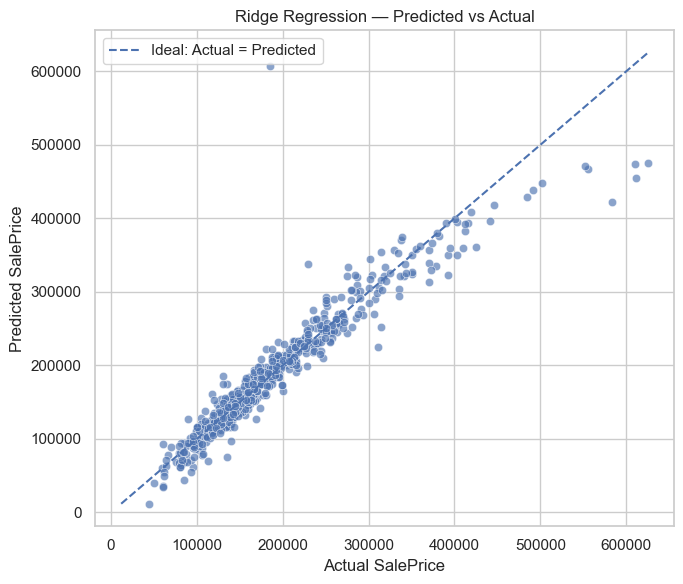

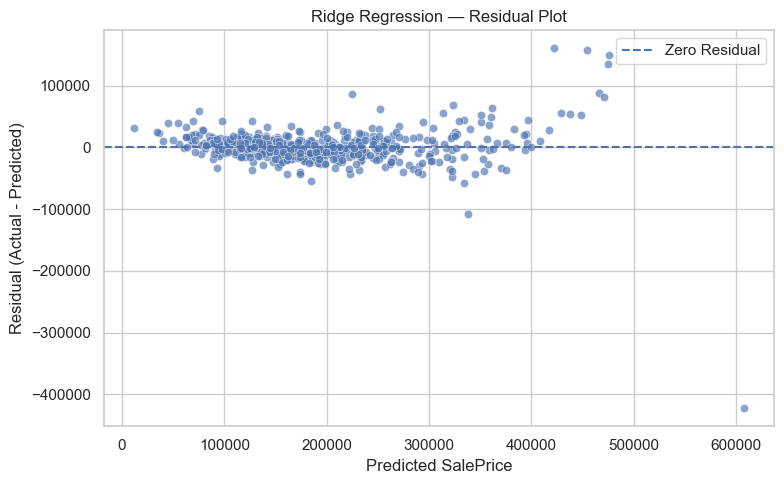

In [10]:
# Predicted vs actual
plt.figure(figsize=(7, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.65)
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
plt.plot(lims, lims, linestyle="--", label="Ideal: Actual = Predicted")
plt.title(f"{MODEL_NAME} — Predicted vs Actual")
plt.xlabel("Actual SalePrice")
plt.ylabel("Predicted SalePrice")
plt.legend()
plt.tight_layout()
plt.show()

# Residual plot
residuals = y_test - y_pred
plt.figure(figsize=(8, 5))
sns.scatterplot(x=y_pred, y=residuals, alpha=0.65)
plt.axhline(0, linestyle="--", label="Zero Residual")
plt.title(f"{MODEL_NAME} — Residual Plot")
plt.xlabel("Predicted SalePrice")
plt.ylabel("Residual (Actual - Predicted)")
plt.legend()
plt.tight_layout()
plt.show()

## 9. Cross-Validation Note

The course requires 5-fold cross-validated R² for the **two best-performing models**. After the common comparison table identifies those two models, run 5-fold CV for them and record the results in the final comparison documentation.

In [11]:
import joblib

model_path = MODELS_DIR / f"{RESULT_FILE}.joblib"
joblib.dump(model, model_path)
print(f"Saved fitted model to: {model_path}")

Saved fitted model to: /Users/venkataramana/Documents/SEMESTERS/5TH SEMESTER/MACHINE LEARNING/ML_Capstone/Review-1/models/ridge_regression.joblib
